In [ ]:
# Imports
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import json

In [ ]:
current_directory = Path.cwd().parent
discharge_directory = Path.joinpath(current_directory, "Data Start Point")

compiled_file_name = Path.joinpath(discharge_directory, "compiled_output.csv")
output_file_name = Path.joinpath(discharge_directory, "final_cleaned_compiled.csv")
points_of_interest_file_name = Path.joinpath(discharge_directory, "points_of_interest.json")

def create_csv_output_file(override=False, csv_data=None):
    if override and Path.exists(output_file_name):
        Path.unlink(output_file_name)
    
    if csv_data is not None:
        csv_data.to_csv(output_file_name, mode='a', header=not Path.exists(output_file_name), index=False)

In [ ]:
combined_df = pd.read_csv(compiled_file_name)
print(combined_df.shape)
print(combined_df.tail())

(10000000, 8)
         Translated Time  Translated Time (minutes)  \
9999995      9725266.849                 162.087781   
9999996      9725267.787                 162.087796   
9999997      9725268.725                 162.087812   
9999998      9725269.664                 162.087828   
9999999      9725270.602                 162.087843   

         ADS Reading 1 (Smoothed and Offset)  Calibrated Current 1  \
9999995                              23305.0            -24.793384   
9999996                              23318.0            -24.757485   
9999997                              23307.0            -24.787861   
9999998                              23318.0            -24.757485   
9999999                              23320.0            -24.751963   

         ADS Reading 2 (Smoothed and Offset)  Calibrated Current 2  \
9999995                                  NaN                   NaN   
9999996                                  NaN                   NaN   
9999997                 

In [24]:
CIRCUIT_CLOSE_VOLTAGE_DROP_THRESHOLD = 0.3
prev_found_time = -999
# 1 sec ~1000 points
# Tuple of time (min) and voltage
last_stable_voltages_before_close = {"index": [], "time": [], "voltage": []}
for index in range(200, len(combined_df) - 10000):
    if index % 10000 == 0:
        #print(f"Processing index {index}/{len(combined_df)}", end="\r")   
        pass
    # Voltage drop + time gap > 1 min + voltage drop > threshold
    if combined_df["Translated Time (minutes)"].iloc[index] - prev_found_time > 1:
        curr = combined_df['Calibrated Voltage'].iloc[index]    # Current point
        following = combined_df['Calibrated Voltage'].iloc[index+9000:index+10000].mean() # Avg of next few point to confirm it is the edge
        next = combined_df['Calibrated Voltage'].iloc[index+90000:index+100000].max() # Ensure that drop is not due to noise
        if curr - following > 0.01 and curr > next + CIRCUIT_CLOSE_VOLTAGE_DROP_THRESHOLD:
            print(f"Found potential circuit close at index {index} with voltage drop from {curr:.2f} V to {next:.2f} V at time {combined_df['Translated Time (minutes)'].iloc[index]:.2f} min.")
            # Take a few step back to get last stable voltage before circuit close
            last_stable_voltages_before_close['index'].append(index)
            last_stable_voltages_before_close['time'].append(combined_df["Translated Time (minutes)"].iloc[index-200:index].mean())
            last_stable_voltages_before_close['voltage'].append(combined_df['Calibrated Voltage'].iloc[index-200:index].mean())
            prev_found_time = combined_df["Translated Time (minutes)"].iloc[index]
    if index % 10000 == 0:
        print(f"Processing index {index} / {len(combined_df)}: Current={curr:.2f} V, Following={following:.2f} V, Next={next:.2f} V", end="\r")
print("Found", len(last_stable_voltages_before_close['time']), "points\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t")
is_close_filtered = False

Found potential circuit close at index 200 with voltage drop from 52.42 V to 49.79 V at time 0.00 min.
Found potential circuit close at index 528595 with voltage drop from 50.75 V to 50.24 V at time 8.48 min.
Found potential circuit close at index 1483134 with voltage drop from 52.83 V to 50.37 V at time 23.96 min.
Found potential circuit close at index 2661550 with voltage drop from 52.63 V to 50.51 V at time 43.52 min.
Found potential circuit close at index 3203471 with voltage drop from 50.50 V to 17.04 V at time 52.23 min.
Found potential circuit close at index 4230212 with voltage drop from 52.33 V to 50.41 V at time 68.80 min.
Found potential circuit close at index 5513911 with voltage drop from 52.22 V to 50.28 V at time 89.60 min.
Found potential circuit close at index 6935926 with voltage drop from 52.19 V to 50.10 V at time 112.61 min.
Found potential circuit close at index 8181448 with voltage drop from 51.90 V to 49.87 V at time 132.79 min.
Found potential circuit close at 

In [ ]:
print(last_stable_voltages_before_close['time'])
print(last_stable_voltages_before_close['voltage'])
to_drop = []
for index in range(1, len(last_stable_voltages_before_close['time'])):
    if last_stable_voltages_before_close['voltage'][index] > last_stable_voltages_before_close['voltage'][index-1]:
        curr_voltage = last_stable_voltages_before_close['voltage'][index]
        for i in range(index):
            if last_stable_voltages_before_close['voltage'][i] < curr_voltage:
                to_drop.append(i)

print("Dropping indices", to_drop)
last_stable_voltages_before_close['time'] = [time for i, time in enumerate(last_stable_voltages_before_close['time']) if i not in to_drop]
last_stable_voltages_before_close['voltage'] = [voltage for i, voltage in enumerate(last_stable_voltages_before_close['voltage']) if i not in to_drop]
print("After dropping, found", len(last_stable_voltages_before_close['time']), "points")

[np.float64(0.000294282331666635)]
[np.float64(52.28376653696498)]
Dropping indices []
After dropping, found 1 points


In [25]:
CIRCUIT_OPEN_VOLTAGE_JUMP_THRESHOLD = 0.5
prev_found_time = -999
# Tuple of time (min) and voltage
last_stable_voltages_before_open = {"index": [], "time": [], "voltage": []}

for index in range(200, len(combined_df)-100000): 
    if index % 1000 == 0:
        print(f"Processing index {index}/{len(combined_df)}", end="\r")   
    # Voltage drop + time gap > 1 min + voltage drop > threshold
    if combined_df["Translated Time (minutes)"].iloc[index] - prev_found_time > 1:
        curr = combined_df['Calibrated Voltage'].iloc[index]
        next = combined_df['Calibrated Voltage'].iloc[index+9000:index+10000].min()
        following = combined_df['Calibrated Voltage'].iloc[index+90000:index+100000].mean() # Avg of next few point to confirm it is the edge
        
        if following - curr > 0.1 and next - curr > CIRCUIT_OPEN_VOLTAGE_JUMP_THRESHOLD:
            print(f"Found potential circuit open at index {index} with voltage jump from {curr:.2f} V to {next:.2f} V at time {combined_df['Translated Time (minutes)'].iloc[index]:.2f} min.")
            # Take a few step back to get last stable voltage before circuit open
            last_stable_voltages_before_open['index'].append(index)
            last_stable_voltages_before_open['time'].append(combined_df["Translated Time (minutes)"].iloc[index-200:index].mean())
            last_stable_voltages_before_open['voltage'].append(combined_df['Calibrated Voltage'].iloc[index-200:index].mean())
            prev_found_time = combined_df["Translated Time (minutes)"].iloc[index]
    
print("Found", len(last_stable_voltages_before_open['time']), "points")
is_open_filtered = False

Found potential circuit open at index 333351 with voltage jump from 50.13 V to 50.65 V at time 5.37 min.
Found potential circuit open at index 775588 with voltage jump from 50.27 V to 50.77 V at time 12.47 min.
Found potential circuit open at index 2083835 with voltage jump from 50.57 V to 51.07 V at time 34.19 min.
Found potential circuit open at index 3587300 with voltage jump from 17.02 V to 50.49 V at time 58.39 min.
Found potential circuit open at index 4867160 with voltage jump from 50.40 V to 50.91 V at time 79.20 min.
Found potential circuit open at index 6138202 with voltage jump from 50.21 V to 50.71 V at time 99.68 min.
Found potential circuit open at index 7548169 with voltage jump from 49.96 V to 50.48 V at time 122.57 min.
Found potential circuit open at index 8802055 with voltage jump from 49.37 V to 49.87 V at time 142.80 min.
Found 8 pointsex 9899000/10000000


In [27]:
# Drop last 4 points from visual inspection of before circuit close
list_to_drop = [0,1,4,10,11]
if not is_close_filtered:
    list_to_drop.sort(reverse=True)
    for i in list_to_drop:
        del last_stable_voltages_before_close['index'][i]
        del last_stable_voltages_before_close['time'][i]
        del last_stable_voltages_before_close['voltage'][i]
    is_close_filtered = True

In [29]:
# Drop last 4 points from visual inspection of before circuit open
list_to_drop = [0]
if not is_open_filtered:
    list_to_drop.sort(reverse=True)
    for i in list_to_drop:
        del last_stable_voltages_before_open['index'][i]
        del last_stable_voltages_before_open['time'][i]
        del last_stable_voltages_before_open['voltage'][i]
    is_open_filtered = True

In [53]:
print(last_stable_voltages_before_open)
print(last_stable_voltages_before_close)

{'index': [775588, 2083835, 3620300, 4867160, 6138202, 7548169, 8802055], 'time': [np.float64(12.4705109035), np.float64(34.18474398275), np.float64(58.90873858333335), np.float64(79.19503159208334), np.float64(99.67650958791668), np.float64(122.57075899191666), np.float64(142.80256090133335)], 'voltage': [np.float64(50.26931548638133), np.float64(50.57320606088349), np.float64(50.5085831998169), np.float64(50.39884246280613), np.float64(50.21225367818724), np.float64(49.9552388189517), np.float64(49.374097138933394)]}
{'index': [1483134, 2661550, 4230212, 5513911, 6935926, 8181448, 9430671], 'time': [np.float64(23.956198208833328), np.float64(43.51606308758333), np.float64(68.80342595075001), np.float64(89.60040762366667), np.float64(112.61237232375001), np.float64(132.7860417939167), np.float64(152.87415153308336)], 'voltage': [np.float64(52.82702795147631), np.float64(52.63496877088578), np.float64(52.325396859693285), np.float64(52.22101401693752), np.float64(52.187961950103), np.f

In [50]:
print(combined_df['Calibrated Voltage'].iloc[3620300])

50.5085831998169


In [51]:
# Replace idx 2 of before open
last_stable_voltages_before_open['index'][2] = 3620300
last_stable_voltages_before_open['voltage'][2] = combined_df['Calibrated Voltage'].iloc[last_stable_voltages_before_open['index'][2]]
last_stable_voltages_before_open['time'][2] = combined_df["Translated Time (minutes)"].iloc[last_stable_voltages_before_open['index'][2]]

In [74]:
print(combined_df['Calibrated Voltage'].iloc[1480000])

52.36579903868163


In [75]:
# Replace idx0 of before close
last_stable_voltages_before_close['index'][0] = 1480000
last_stable_voltages_before_close['voltage'][0] = combined_df['Calibrated Voltage'].iloc[last_stable_voltages_before_close['index'][0]]
last_stable_voltages_before_close['time'][0] = combined_df["Translated Time (minutes)"].iloc[last_stable_voltages_before_close['index'][0]]

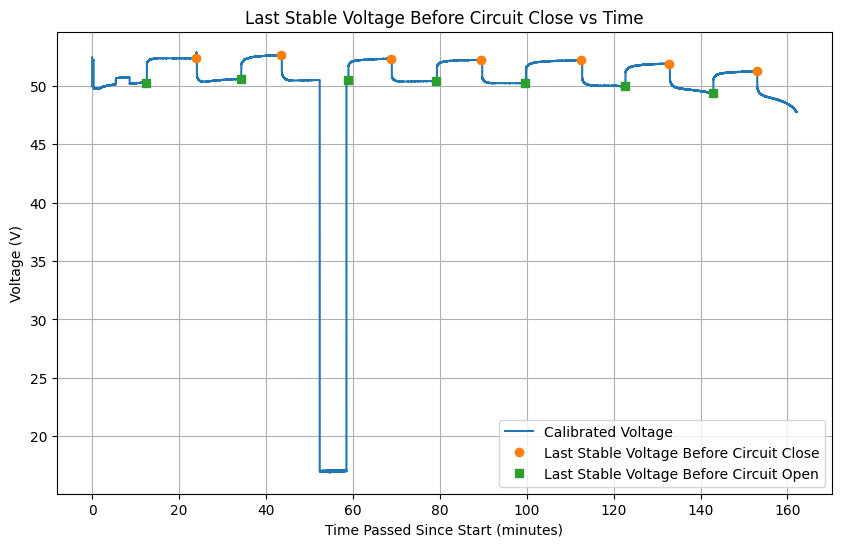

In [76]:
plt.figure(figsize=(10, 6))
plt.plot(combined_df['Translated Time (minutes)'], combined_df['Calibrated Voltage'], label='Calibrated Voltage')
plt.plot(last_stable_voltages_before_close['time'], last_stable_voltages_before_close['voltage'], 'o', label='Last Stable Voltage Before Circuit Close')
plt.plot(last_stable_voltages_before_open['time'], last_stable_voltages_before_open['voltage'], 's', label='Last Stable Voltage Before Circuit Open')
plt.xlabel('Time Passed Since Start (minutes)')
plt.ylabel('Voltage (V)')
plt.title('Last Stable Voltage Before Circuit Close vs Time')
plt.legend()
plt.grid()
plt.show()

In [19]:
isCloseFiltered = False
isOpenFiltered = False

In [77]:
create_csv_output_file(override=True, csv_data=combined_df)

In [78]:
outpus_json_points = {
    "before_close": {
        "index": last_stable_voltages_before_close['index'],
        "time": last_stable_voltages_before_close['time'],
        "voltage": last_stable_voltages_before_close['voltage']
    },
    "before_open": {
        "index": last_stable_voltages_before_open['index'],
        "time": last_stable_voltages_before_open['time'],
        "voltage": last_stable_voltages_before_open['voltage']
    }
}
print(f"Saved {len(last_stable_voltages_before_close['index'])} points for before close and {len(last_stable_voltages_before_open['time'])} points for before open to {points_of_interest_file_name}.")
json.dump(outpus_json_points, open(points_of_interest_file_name, 'w'), indent=4)

Saved 7 points for before close and 7 points for before open to c:\Users\Kor\Documents\GitHub\Proa-II-Electrical-Setup\Calibration Data 2\Data\Data Start Point\points_of_interest.json.
